# **Part 3:** Visualization of Model Results

**Author:** Jack Logan <br>
**Last Updated:** May 7, 2025

### Agenda:

In this notebook, we will: 
- Visualize preliminary model results
- Generate geospatial maps of model domain and results
- Compare modeled and simulated values for concentration and head

In [1]:
import flopy
import flopy.mf6 as mf6
import flopy.plot as fplt

import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm

import cartopy
import cartopy.crs as ccrs
from cartopy.io.img_tiles import GoogleTiles

import findwells as fw

from sklearn.metrics import mean_squared_error, r2_score

# Load Simulation

The best way to access the model outputs is using the built-in flopy methods. First, we load in the simulation like in Part 2. Then we get each model, and access the data from there.

In [2]:
# Load Simulation
sim = mf6.MFSimulation.load(sim_name='peterson', exe_name='../bin/mf6.exe', sim_ws='../model/inputs/')

loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    loading package ic...
    loading package npf...
    loading package sto...
    loading package chd...
    loading package riv...
    loading package wel...
    loading package rch...
    loading package obs...
    loading package oc...
  loading model gwt6...
    loading package dis...
    loading package ic...
    loading package adv...
    loading package dsp...
    loading package mst...
    loading package ist...
    loading package cnc...
    loading package ssm...
    loading package obs...
    loading package oc...
  loading model gwt6...
    loading package dis...
    loading package ic...
    loading package adv...
    loading package dsp...
    loading package mst...
    loading package ist...
    loading package cnc...
    loading package ssm...
    loading package obs...
    loading package oc...
  loading model gwt6...
    loading packag

## Load Models

In [3]:
# Grab groundwater flow model from simulation
gwf = sim.get_model('peterson_flow')

# Grab transport model for each solute
solutes = ['pfos', 'pfoa', 'pfhxs']
gwt = {
    solute : sim.get_model(f'peterson_{solute}') for solute in solutes
}

## Load in Model Data

In [4]:
# read head outputs from model object
head_obj = gwf.output.head()
heads = head_obj.get_alldata()

# read conc outputs from all three models
conc_objects = {
    solute : gwt[solute].output.concentration() for solute in solutes
}

# Get full timeseries data for all concentrations
pfos, pfoa, pfhxs = [conc_objects[solute].get_alldata() for solute in solutes]

# Visualize Model Domain

The one plot I made before doing that crazy shit w/ Aaron's figure. Visualize the flow and transport model in a 2 panel plot. 
- Left panel: Flow model, head wells, head contours
- Right panel: Transport model, conc wells, conc contours(?)

Using Cartopy to make GeoAxes, which will georeference the plot. Using `plt.subplots()` to make the matplotlib figure passing the dictionary `{'projection':ccrs.UTM(13)}` to subplot_kw, the plot will georeference to UTM zone 13. There are many other coordinate reference systems supported by Cartopy, so read the `cartopy.crs` documentation for more information about how to turn your specific coordinated to a georeferenced map. If you don't have a georeference model , you can skip any of the cartopy code and still make model visualizations.

In [5]:
heads.shape

(328, 1, 972, 700)

The head data is a 4D array. The axis correspond to (time, layer, row, column). Matplotlib likes 2D arrays to plot. So, we'll pick a time and a layer

In [6]:
# Get the last timestep, first layer, all rows all columns
heads[-1, 0, :, :].shape

(972, 700)

Now we're in two dimensions. Let's roll:

In [7]:
head_obs = gwf.get_package('obs')
head_rec = head_obs.continuous.data['../outputs/head_obs.csv']

xs_head = []
ys_head = []
for k, i, j in head_rec['id']:
    # Convert to real-world coordinates depending on grid type
    xs_head.append(gwf.modelgrid.xcellcenters[i, j])  # converts (row, col) to x, y
    ys_head.append(gwf.modelgrid.ycellcenters[i, j])

In [8]:
conc_obs = gwt['pfos'].get_package('obs')
conc_rec = conc_obs.continuous.data['../outputs/pfos_obs.csv']

xs_conc = []
ys_conc = []
for k, i, j in conc_rec['id']:
    # Convert to real-world coordinates depending on grid type
    xs_conc.append(gwf.modelgrid.xcellcenters[i, j])
    ys_conc.append(gwf.modelgrid.ycellcenters[i, j])

In [9]:
pfos_plot = np.where(pfos[-1, 0, :,:] != 1e30, pfos[-1, 0, :,:]*1e6, 1e30)

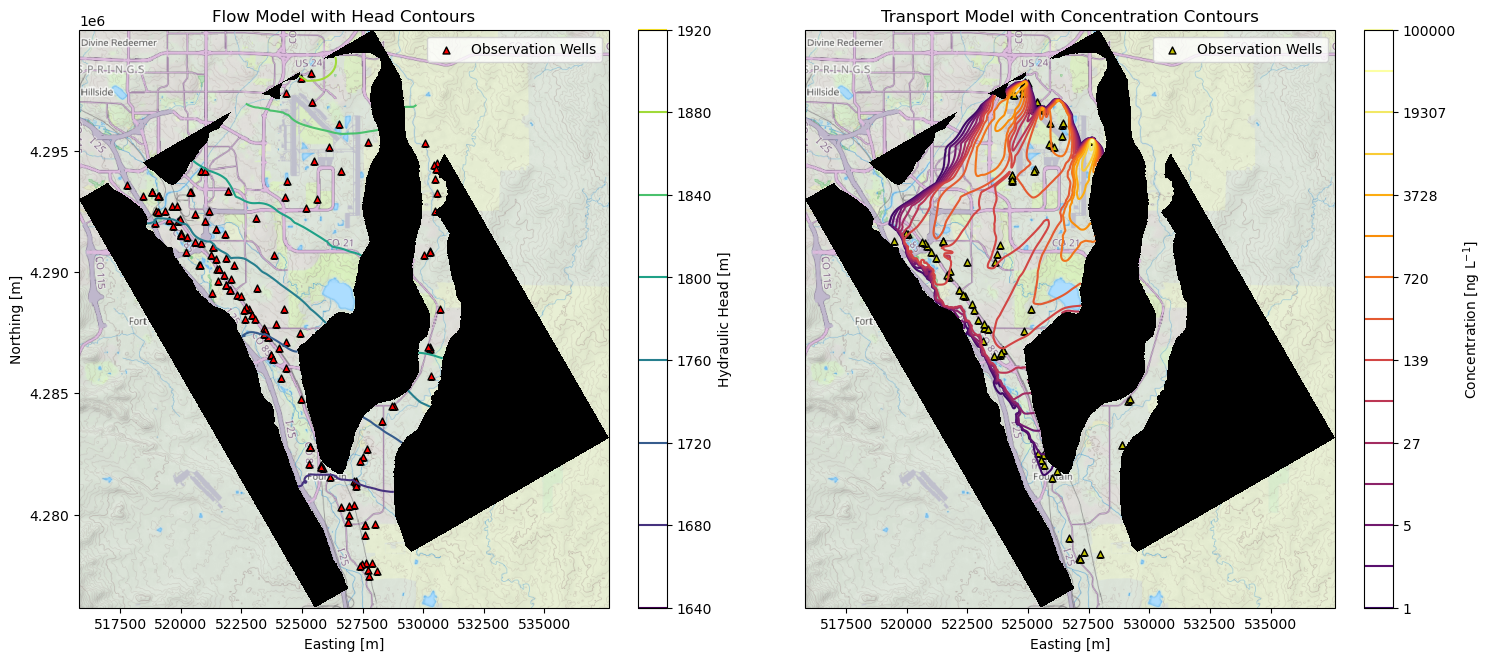

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(15,6.5), subplot_kw={'projection':ccrs.UTM(13)}, layout='constrained')  # 1 row, 2 cols
ax1, ax2 = axs

mv = fplt.PlotMapView(model=gwf)  # Used to plot array as it appears in the real worls

# Plot heads on left
ax1.scatter(xs_head, ys_head, c='r', marker='^', ec='k', transform=ccrs.UTM(13), s=25, label='Observation Wells')
cs1 = mv.contour_array(heads[-1, 0, :, :], ax=ax1)
fig.colorbar(cs1, ax=ax1, label='Hydraulic Head [m]')

ax1.set_title('Flow Model with Head Contours')

# Plot 
norm = SymLogNorm(1e0, vmin=0, vmax=pfos_plot[pfos_plot != 1e30].max())  # Use symmetric log nor,
levels = np.logspace(0, 5, num=15)
cs2 = mv.contour_array(pfos_plot, ax=ax2, norm=norm, levels=levels, cmap='inferno')
fig.colorbar(cs2, ax=ax2, label='Concentration [ng L$^{-1}$]')

ax2.scatter(xs_conc, ys_conc, c='y', marker='^', ec='k', transform=ccrs.UTM(13), s=25, label='Observation Wells')
ax2.set_title('Transport Model with Concentration Contours')

ggtiles = GoogleTiles(url='https://tile.thunderforest.com/landscape/{z}/{x}/{y}.png?apikey=35fc333976e345c4ba0a56bf2bf17ee7')
for ax in axs:
    mv.plot_inactive(ax=ax, transform=ccrs.UTM(13))
    ax.add_image(ggtiles, 12)
    ax.legend(loc='upper right')

ax1.set_ylabel('Northing [m]')
ax1.set_xlabel('Easting [m]')
ax2.set_xlabel('Easting [m]')

ax1.set_yticks([4280000, 4285000, 4290000, 4295000])
ax1.set_xticks([517500, 520000, 522500, 525000, 527500, 530000, 532500, 535000,])
ax2.set_xticks([517500, 520000, 522500, 525000, 527500, 530000, 532500, 535000,])

plt.show()

# Head Data

Plot model domain heads, with contours

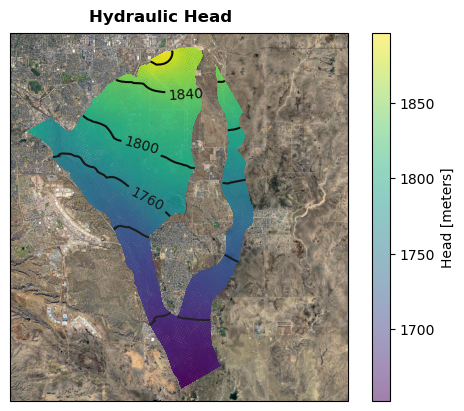

In [11]:
fig, ax = plt.subplots(subplot_kw={'projection':ccrs.UTM(13)}, layout='constrained', figsize=(6,4), )#dpi=300)

modelmap = fplt.PlotMapView(model=gwf)

vmax = heads[heads!=1e30].max()
vmin = heads[heads!=1e30].min()
cellhead = modelmap.plot_array(heads[0], ax=ax, cmap='viridis', 
                               transform=ccrs.UTM(13), alpha=0.5)
fig.colorbar(cellhead, ax=ax, label='Head [meters]')

contour = modelmap.contour_array(heads[0], ax=ax, vmin=0,
                                 transform=ccrs.UTM(13), cmap='Grays')

ggtiles = GoogleTiles(style='satellite')
ax.add_image(ggtiles, 13)
ax.set_xlabel('Easting [meters]')
ax.set_ylabel('Northing [meters]')
ax.clabel(contour)

plt.suptitle('Hydraulic Head', weight='bold')
plt.show()

## Plot Observed vs Simulated Heads

First, load in the head data

In [12]:
# Read in simulated observations to a dataframe
sim_head = pd.read_csv('../model/outputs/head_obs.csv', index_col='time')
sim_head.head()

,FOUNTAINNO.1,SC01406518ACDT02-MW006,SC01406518CAAMW1-1,SC01406519ABDT04-MW004,SC01406519BBBT01-MW002,SC01406520CDBMW2-4,SC01406527ACB1,SC01406527DDB1BANNING-LEWISRANCHES,SC01406527DDB2,SC01406527DDC1,...,SCO1506602BBBTH-18,SCO1506602BDC,SCO1506602CAA,SCO1506603AAD,SCO1506603BAC,SCO1506604AAA,SCO1506604AABTH-49,SCO1506604ABA2TH-50,SCO1506610BAA,SCO1506611ABCTH-47
time,,,,,,,,,,,,,,,,,,,,,
59.0,1681.987735,1883.974514,1877.745285,1855.669695,1860.766222,1841.273764,1819.584478,1811.700325,1809.746561,1807.650279,...,1778.666146,1770.321412,1769.961186,1772.251807,1763.170947,1764.173832,1762.194710,1762.218579,1749.725740,1751.961208
89.0,1681.974959,1883.970374,1877.738288,1855.606681,1860.751174,1841.147646,1819.704667,1811.782336,1809.864378,1807.751710,...,1778.639413,1770.300324,1769.937267,1772.232234,1763.119837,1763.941931,1762.523957,1762.589654,1749.724715,1751.953974
274.0,1681.862768,1883.904718,1877.597708,1854.899953,1860.330085,1840.018757,1819.729684,1812.105291,1810.300276,1808.226024,...,1777.847622,1769.784646,1769.504366,1771.614906,1762.710238,1763.545422,1762.444138,1762.537636,1749.707116,1751.819917
304.0,1681.838511,1883.894573,1877.575874,1854.842876,1860.304820,1839.908327,1819.716013,1812.158926,1810.365286,1808.296597,...,1777.788589,1769.743838,1769.453639,1771.581038,1762.658464,1763.489846,1762.431202,1762.528917,1749.706592,1751.796851
365.0,1681.805776,1883.876904,1877.545277,1854.660518,1860.233011,1839.538880,1819.695268,1812.239054,1810.471846,1808.419822,...,1777.521918,1769.593066,1769.327954,1771.390284,1762.560118,1763.425641,1762.416448,1762.518969,1749.702606,1751.747423


In [13]:
obs_head = pd.read_csv('../model/data/flow/observed-heads.csv', index_col='time')
obs_head.head()

,FOUNTAINNO.1,SC01406518ACDT02-MW006,SC01406518CAAMW1-1,SC01406519ABDT04-MW004,SC01406519BBBT01-MW002,SC01406520CDBMW2-4,SC01406527ACB1,SC01406527DDB1BANNING-LEWISRANCHES,SC01406527DDB2,SC01406527DDC1,...,SCO1506602BBBTH-18,SCO1506602BDC,SCO1506602CAA,SCO1506603AAD,SCO1506603BAC,SCO1506604AAA,SCO1506604AABTH-49,SCO1506604ABA2TH-50,SCO1506610BAA,SCO1506611ABCTH-47
time,,,,,,,,,,,,,,,,,,,,,
59,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
89,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
454,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
639,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
789,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1802.757888,1803.123648,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


We will align to the two dataframes here so they have the same size. Additionall, the following wells had bad recorded data, so we will exclude them here:

In [14]:
wells_to_exclude = [
    'SCO1506601BBDTH-53',
    'SC01406528BBC03-002',
    'SC01506522DBB1',
    'SC01506503AAB2',
    'SC01406635CAACO259-26',
    'SC01506612CDCCO259-25',
    'SCO1506603AAD',
    'SC01406529CDDPAFB07MW03',
    'SCO1506602BBBTH-18',
    'SC01506603DDBSECURITY14',
    'SC01406527DDB1BANNING-LEWISRANCHES',
    'SC01406527DDB2',
    'SC01406531BBCT13-MW004',
    'SC01506603DCA1',
    'SC01506613ADD'
]

# Align sim_df and obs_df by their common indices
common_index = sim_head.index.intersection(obs_head.index)

# Use only the rows corresponding to the common index, drop bad wells
sim_head = sim_head.loc[common_index, :].drop(columns=wells_to_exclude)
obs_head = obs_head.loc[common_index, :].drop(columns=wells_to_exclude)

We want to compute some spatial statistics, but we have a not of NaN values. We must mask those before computing the RSME and R$^{2}$ values.

In [15]:
# Turn all data into 1D numpy arrays
obs_vals = obs_head.values.flatten()
sim_vals = sim_head.values.flatten()

# Get NaN mask
mask = obs_head.notna().values.flatten()

# Get only real data
obs_vals = obs_vals[mask]
sim_vals = sim_vals[mask]

# Compute RMSE and R^2
rmse = np.sqrt(mean_squared_error(obs_vals, sim_vals))
r2 = r2_score(obs_vals, sim_vals)

Now we can plot the observed and simulated heads on a 1-1 line with the RMSE and the R$^{2}$ values.

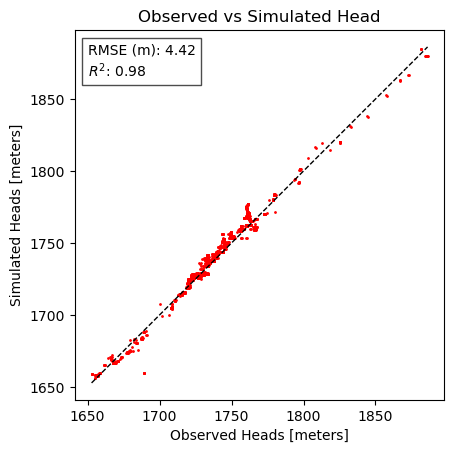

In [16]:
fig, ax = plt.subplots()

ax.scatter(obs_head, sim_head, color='r', s=1)

# 1:1 Line
min_val, max_val = min(obs_vals.min(), sim_vals.min()), max(obs_vals.max(), sim_vals.max())
ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=1)

# Display metrics on the plot
ax.text(0.035, 0.875, f'RMSE (m): {rmse:.2f}\n$R^2$: {r2:.2f}', transform=ax.transAxes, fontsize=10, bbox=dict(facecolor='white', alpha=0.7))

ax.set_xlabel('Observed Heads [meters]')
ax.set_ylabel('Simulated Heads [meters]')
ax.set_aspect('equal')
#ax.grid(ls='--', color='gray', alpha=0.5)

ax.set_title('Observed vs Simulated Head')

plt.show()

In [17]:
# Create a dictionary to hold residuals per well
residuals_by_well = {}

for col in sim_head.columns:
    obs = obs_head[col]
    sim = sim_head[col]
    # Mask NaNs
    mask = ~np.isnan(obs) & ~np.isnan(sim)
    if mask.sum() == 0:
        continue
    residuals = sim[mask] - obs[mask]
    mean_abs_residual = np.mean(np.abs(residuals))
    residuals_by_well[col] = mean_abs_residual

# Sort wells by highest mean absolute residual
sorted_residuals = sorted(residuals_by_well.items(), key=lambda x: x[1], reverse=True)

# Print top 5 wells with highest residuals
print("Top 20 wells with highest mean absolute residuals:")
for well, res in sorted_residuals[:20]:
    print(f"{well}: {res:.2f} m")

Top 20 wells with highest mean absolute residuals:
SC01606516CCC1: 29.57 m
SC01506603ABATH-22: 11.99 m
SC01506603BCA2: 11.69 m
SC01606505DDC2: 9.26 m
SC01506612ABA: 8.91 m
SCO1506602CAA: 7.75 m
SCO1506602BDC: 7.58 m
SC01406531CBC04-009: 7.54 m
SCO1406634CCD: 7.09 m
SC01506619ADA2: 7.02 m
SC01406527ACB1: 6.89 m
SC01506603CAB4: 6.85 m
SC01506611DCB2: 6.79 m
SC01506603CAB5: 6.73 m
SC01406529BCBT07-MW004: 6.65 m
SC01506510ABA: 6.54 m
SC01506530CDAFRANCOIS: 6.50 m
SCO1506611ABCTH-47: 6.45 m
SC01606505DDC: 6.36 m
SC01406519BBBT01-MW002: 6.32 m


# Plot Concentration Results

In [18]:
# Load in OBS well locations
obs_wells = pd.read_csv('../model/data/transport/observation-wells.csv')

# Get real world xy for each well
x = gwt['pfos'].modelgrid.xcellcenters[obs_wells['row'].to_numpy('int64'), obs_wells['column'].to_numpy('int64')]
y = gwt['pfos'].modelgrid.ycellcenters[obs_wells['row'].to_numpy('int64'), obs_wells['column'].to_numpy('int64')]

## PFOS Results

First, let's look at the PFOS results given that these are the most important ones.

### Plume Map

Next, we'll plot the plume map with well locations. One important thing to note, sometimes MODFLOW outputs 0 concentrations as *very* small negative concentrations. This means we have to use the `SymLogNorm` from `matplotlib.colors`. This allows us to handle the negative and zero values accordingly.

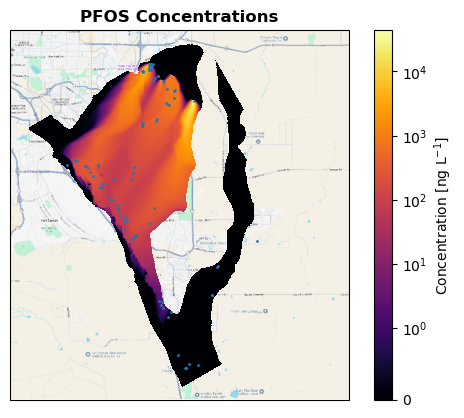

In [19]:
fig, ax = plt.subplots(subplot_kw={'projection':ccrs.UTM(13)})

mv = fplt.PlotMapView(model=gwt['pfos'])

norm = SymLogNorm(1e0, vmin=0, vmax=pfos_plot[pfos_plot != 1e30].max())  # Linear threshold at 1 ng/l, vmin at 0
cs = mv.plot_array(pfos_plot, ax=ax, norm=norm, cmap='inferno')
fig.colorbar(cs, ax=ax, label="Concentration [ng L$^{-1}$]")

ax.scatter(x, y, transform=ccrs.UTM(13), s=1)  # Scatter plot with Obs wells

ggtiles = GoogleTiles()
ax.add_image(ggtiles, 13)
ax.set_title('PFOS Concentrations', weight='bold')

plt.show()

### Observed vs Simulated concentration

First, load in the simulated data. We determined that our sampling event, which was in May of 2018, occurred closest to the model day `17713`. We will get the closest simulated concentrations from the model. 

In [20]:
# Read in simulated observations to a dataframe
sim_conc = pd.read_csv('../model/outputs/pfos_obs.csv', index_col='time')

closest_index = sim_conc.index[(np.abs(sim_conc.index - 17713)).argmin()]
sim_conc = sim_conc.loc[closest_index]

Read in observed data and make the Well names the columns

In [21]:
obs_conc = pd.read_csv('../model/data/transport/targets-downstream.csv', index_col='Well Name').T

Now we can get the matching simulated and observated data:

In [22]:
common_index = obs_conc.columns.intersection(sim_conc.index)

sim = sim_conc.loc[common_index]
obs = obs_conc.T.loc[common_index, "PFOS (ng/L)"]

And plot the data on a 1-1 plot below:

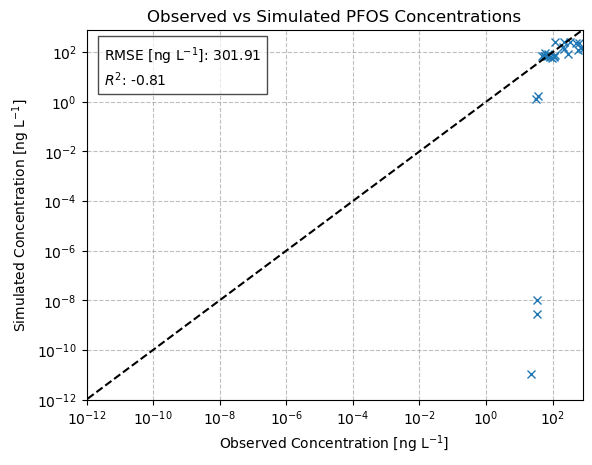

In [23]:
vmin = min(obs.min(), sim.min())
vmax = max(obs.max(), sim.max())
xy = np.linspace(vmin, vmax, 10)

fig, ax = plt.subplots()

ax.loglog(obs, sim*1e6, marker='x', ls='')
ax.plot(xy, xy, linestyle='--', c='k')
ax.grid(ls='--', color='grey', alpha=0.5)

ax.set_xlabel('Observed Concentration [ng L$^{-1}$]')
ax.set_ylabel('Simulated Concentration [ng L$^{-1}$]')
ax.set_ylim(1e-12, vmax)
ax.set_xlim(1e-12, vmax)

rmse = np.sqrt(mean_squared_error(obs, sim))
r2 = r2_score(obs, sim)

ax.text(0.035, 0.85, f'RMSE [ng L$^{{-1}}$]: {rmse:.2f}\n$R^2$: {r2:.2f}', transform=ax.transAxes, fontsize=10, bbox=dict(facecolor='white', alpha=0.7))

ax.set_title('Observed vs Simulated PFOS Concentrations')

plt.show()

Here we can see that the marjority of the data points fall on this 1-1 line, except for 3 wells, which are 8 to 10 orders of magnitude under their observed values. Let's first looks closer to see how well this cluster in the upper right actually fits.

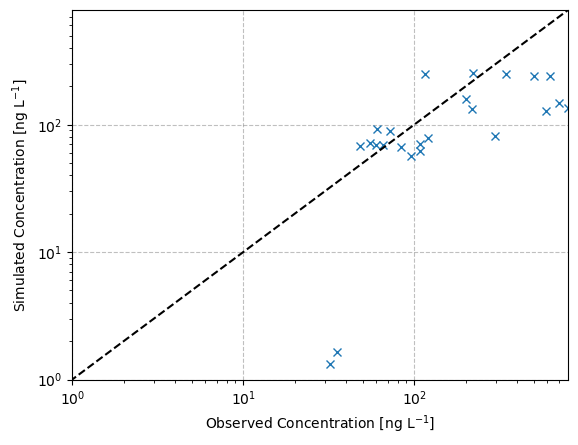

In [24]:
vmin = min(obs.min(), sim.min())
vmax = max(obs.max(), sim.max())
xy = np.linspace(vmin, vmax, 10)

fig, ax = plt.subplots()

ax.loglog(obs, sim*1e6, marker='x', ls='')
ax.plot(xy, xy, linestyle='--', c='k')
ax.grid(ls='--', color='grey', alpha=0.5)

ax.set_xlabel('Observed Concentration [ng L$^{-1}$]')
ax.set_ylabel('Simulated Concentration [ng L$^{-1}$]')
ax.set_ylim(1e0, vmax)
ax.set_xlim(1e0, vmax)

plt.show()

## All Transport Model Results


### Three panel Plume


In [25]:
pfoa_plot = np.where(pfoa[-1, 0, :,:] != 1e30, pfoa[-1, 0, :,:]*1e6, 1e30)
pfhxs_plot = np.where(pfhxs[-1, 0, :,:] != 1e30, pfhxs[-1, 0, :,:]*1e6, 1e30)

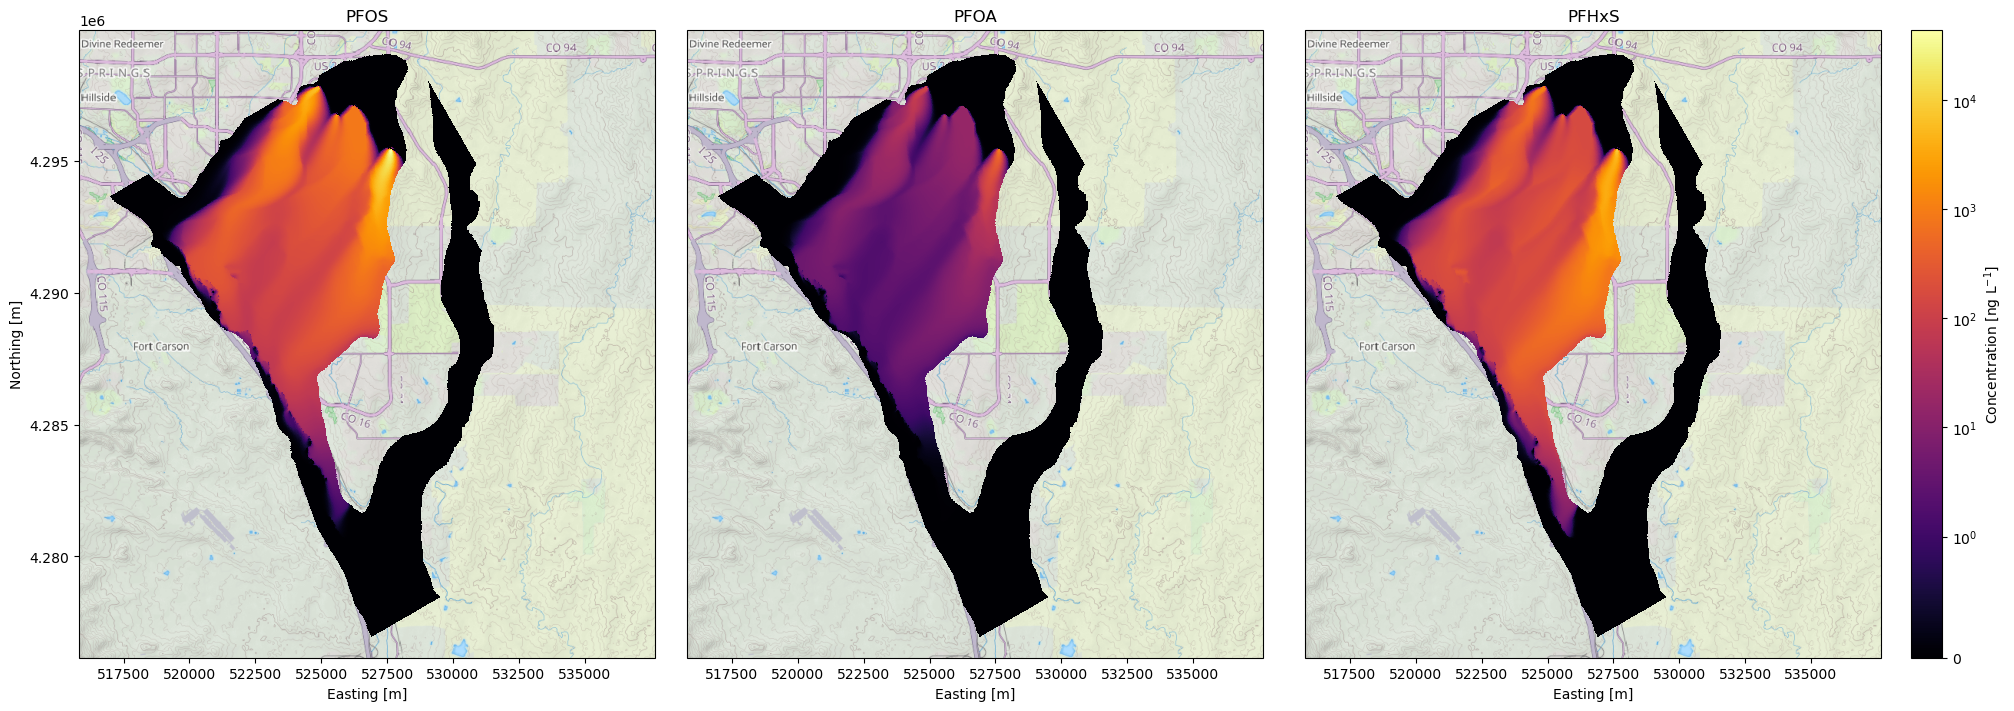

In [26]:
fig, axs = plt.subplots(1, 3, figsize=(20,7), layout='constrained', subplot_kw={'projection':ccrs.UTM(13)})
ax1, ax2, ax3 = axs

# Plot on mapview, give each the same colorscale
mv = fplt.PlotMapView(model=gwt['pfos'])
norm = SymLogNorm(1e0, vmin=0, vmax=pfos_plot[pfos_plot != 1e30].max())

# Plot PFOS
mv.plot_array(pfos_plot, ax=ax1, norm=norm, cmap='inferno')
ax1.set_title('PFOS')

# Plot PFOA
mv.plot_array(pfoa_plot, ax=ax2, norm=norm, cmap='inferno')
ax2.set_title('PFOA')

# 
cs = mv.plot_array(pfhxs_plot, ax=ax3, norm=norm, cmap='inferno')
fig.colorbar(cs, ax=ax3, label='Concentration [ng L$^{-1}$]')
ax3.set_title('PFHxS')

ax1.set_ylabel('Northing [m]')
ax1.set_xlabel('Easting [m]')
ax2.set_xlabel('Easting [m]')
ax3.set_xlabel('Easting [m]')

ax1.set_yticks([4280000, 4285000, 4290000, 4295000])
ax1.set_xticks([517500, 520000, 522500, 525000, 527500, 530000, 532500, 535000,])
ax2.set_xticks([517500, 520000, 522500, 525000, 527500, 530000, 532500, 535000,])
ax3.set_xticks([517500, 520000, 522500, 525000, 527500, 530000, 532500, 535000,])

ax2.set_yticks([])
ax3.set_yticks([])

ggtiles = GoogleTiles(url='https://tile.thunderforest.com/landscape/{z}/{x}/{y}.png?apikey=35fc333976e345c4ba0a56bf2bf17ee7')
for ax in axs:
    ax.add_image(ggtiles, 12)
    ax.set_aspect('equal')

### Three Panel 1-1

- [ ] Three-panel modeled vs simulated w/ some statistics

Each models 1-1 plot, include RMSE and such

In [27]:
sim_pfos = pd.read_csv('../model/outputs/pfos_obs.csv', index_col='time')
sim_pfoa = pd.read_csv('../model/outputs/pfoa_obs.csv', index_col='time')
sim_pfhxs = pd.read_csv('../model/outputs/pfhxs_obs.csv', index_col='time')

In [28]:
sim_pfos = sim_pfos.loc[closest_index, common_index] * 1e6
sim_pfoa = sim_pfoa.loc[closest_index, common_index] * 1e6
sim_pfhxs = sim_pfhxs.loc[closest_index, common_index] * 1e6

obs_pfos = obs_conc.loc['PFOS (ng/L)', common_index]
obs_pfoa = obs_conc.loc['PFOA (ng/L)', common_index]
obs_pfhxs = obs_conc.loc['PFHxS (ng/L)', common_index]

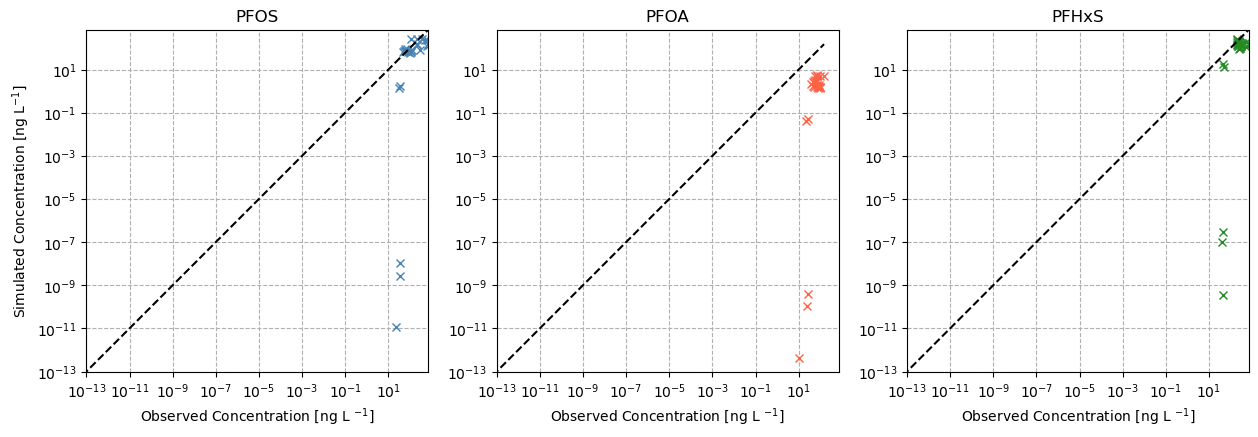

In [29]:
fig, axs = plt.subplots(1, 3, figsize=(15,5))
ax1, ax2, ax3 = axs

ax1.loglog(obs_pfos, sim_pfos, marker='x', ls='', color='steelblue')
ax1.set_title('PFOS')

vmin = min(obs_pfos.min(), sim_pfos.min())
vmax = max(obs_pfos.max(), sim_pfos.max())
xy = np.linspace(vmin, vmax, 10)
ax1.plot(xy, xy, ls='--', c='k')

ax2.loglog(obs_pfoa, sim_pfoa, marker='x', ls='', color='tomato')
ax2.set_title('PFOA')

vmin = min(obs_pfoa.min(), sim_pfoa.min())
vmax = max(obs_pfoa.max(), sim_pfoa.max())
xy = np.linspace(vmin, vmax, 10)
ax2.plot(xy, xy, ls='--', c='k')

ax3.loglog(obs_pfhxs, sim_pfhxs, marker='x', ls='', color='forestgreen')
ax3.set_title('PFHxS')

vmin = min(obs_pfhxs.min(), sim_pfhxs.min())
vmax = max(obs_pfhxs.max(), sim_pfhxs.max())
xy = np.linspace(vmin, vmax, 10)
ax3.plot(xy, xy, ls='--', c='k')

ax1.set_ylabel('Simulated Concentration [ng L$^{-1}$]')
ax1.set_xlabel('Observed Concentration [ng L $^{-1}$]')
ax2.set_xlabel('Observed Concentration [ng L $^{-1}$]')
ax3.set_xlabel('Observed Concentration [ng L $^{-1}$]')
for ax in axs:
    ax.set_xlim(1e-13, vmax)
    ax.set_ylim(1e-13, vmax)
    ax.set_aspect('equal')
    ax.grid(ls='--')

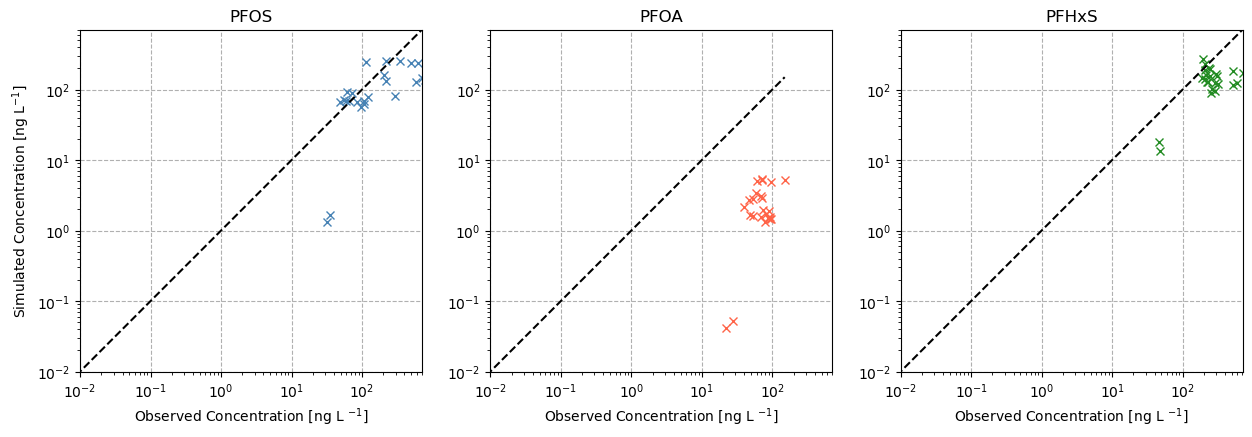

In [30]:
fig, axs = plt.subplots(1, 3, figsize=(15,5))
ax1, ax2, ax3 = axs

ax1.loglog(obs_pfos, sim_pfos, marker='x', ls='', color='steelblue')
ax1.set_title('PFOS')

vmin = min(obs_pfos.min(), sim_pfos.min())
vmax = max(obs_pfos.max(), sim_pfos.max())
xy = np.linspace(vmin, vmax, 10)
ax1.plot(xy, xy, ls='--', c='k')

ax2.loglog(obs_pfoa, sim_pfoa, marker='x', ls='', color='tomato')
ax2.set_title('PFOA')

vmin = min(obs_pfoa.min(), sim_pfoa.min())
vmax = max(obs_pfoa.max(), sim_pfoa.max())
xy = np.linspace(vmin, vmax, 10)
ax2.plot(xy, xy, ls='--', c='k')

ax3.loglog(obs_pfhxs, sim_pfhxs, marker='x', ls='', color='forestgreen')
ax3.set_title('PFHxS')

vmin = min(obs_pfhxs.min(), sim_pfhxs.min())
vmax = max(obs_pfhxs.max(), sim_pfhxs.max())
xy = np.linspace(vmin, vmax, 10)
ax3.plot(xy, xy, ls='--', c='k')

ax1.set_ylabel('Simulated Concentration [ng L$^{-1}$]')
ax1.set_xlabel('Observed Concentration [ng L $^{-1}$]')
ax2.set_xlabel('Observed Concentration [ng L $^{-1}$]')
ax3.set_xlabel('Observed Concentration [ng L $^{-1}$]')
for ax in axs:
    ax.set_xlim(1e-2, vmax)
    ax.set_ylim(1e-2, vmax)
    ax.set_aspect('equal')
    ax.grid(ls='--')

## Well Breakthrough Curves

Plot breakthrough curves at each well, with a point for each observation. Ideally, you would have multiple observations and could compare the breakthroughs directly.

In [31]:
sim_pfos = pd.read_csv('../model/outputs/pfos_obs.csv', index_col='time')
sim_pfoa = pd.read_csv('../model/outputs/pfoa_obs.csv', index_col='time')
sim_pfhxs = pd.read_csv('../model/outputs/pfhxs_obs.csv', index_col='time')

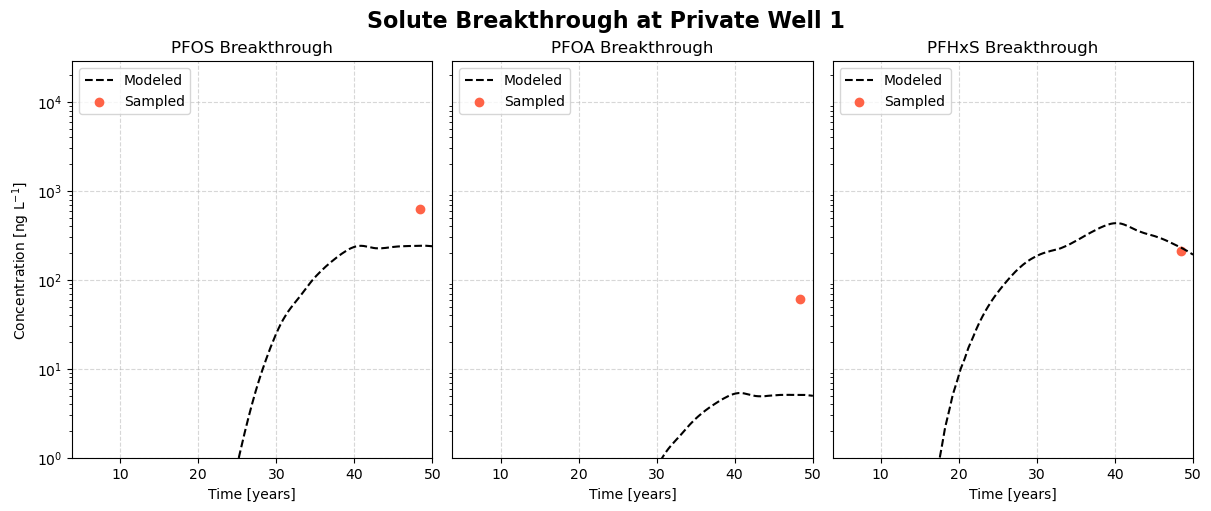

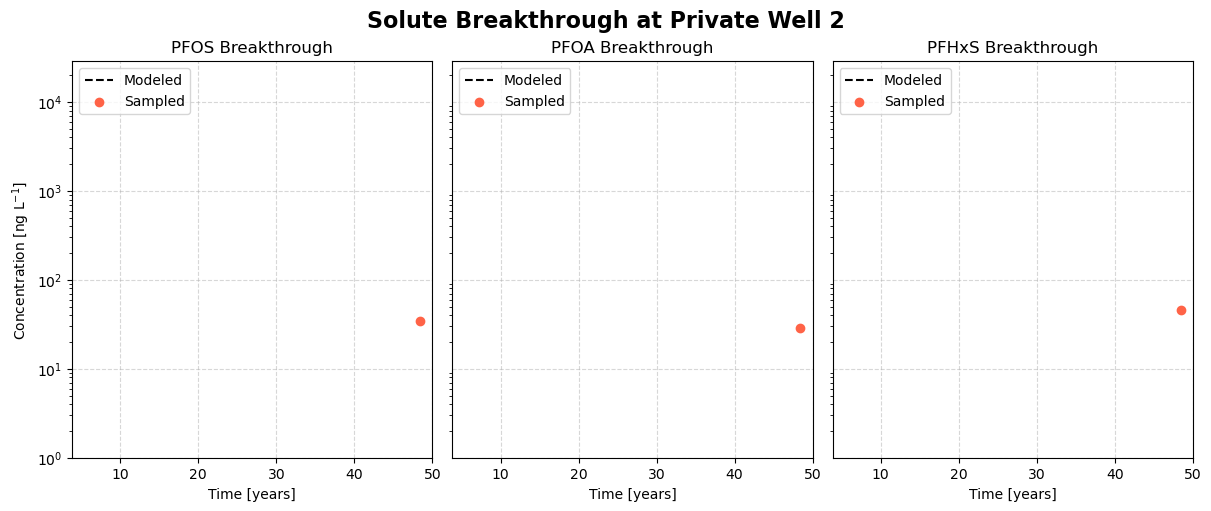

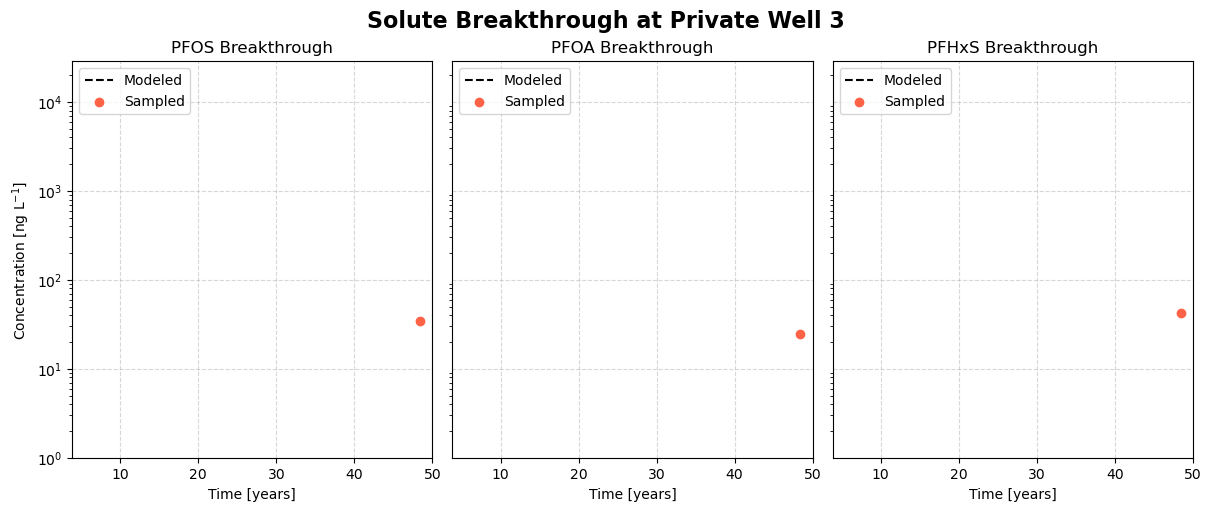

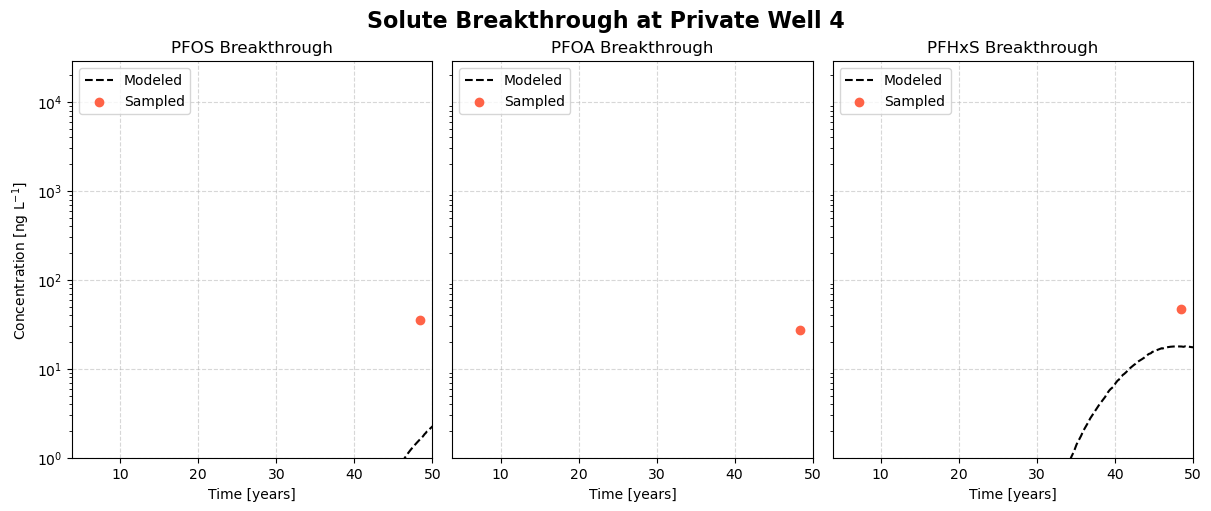

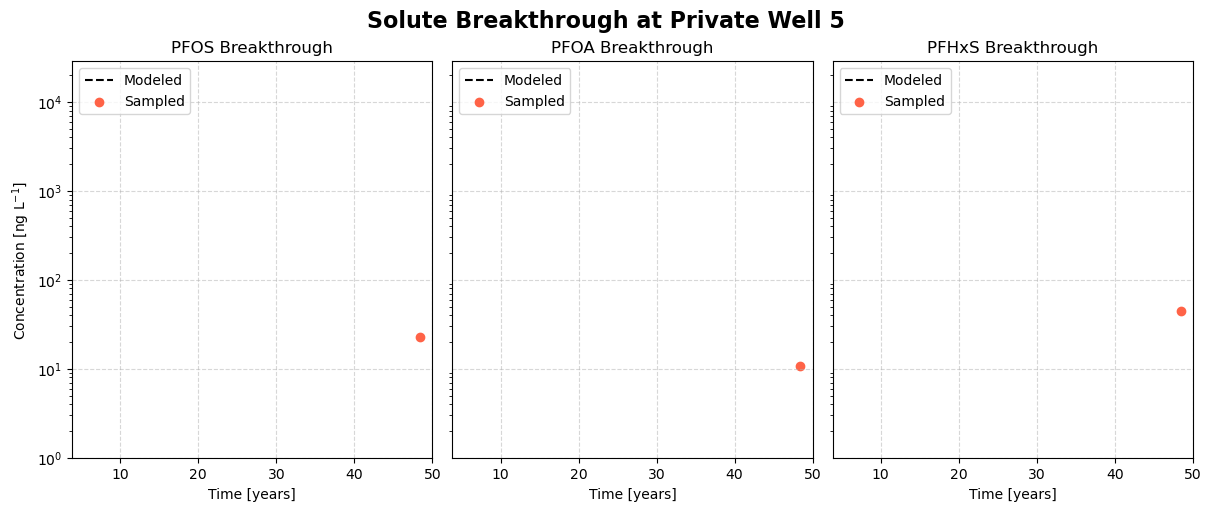

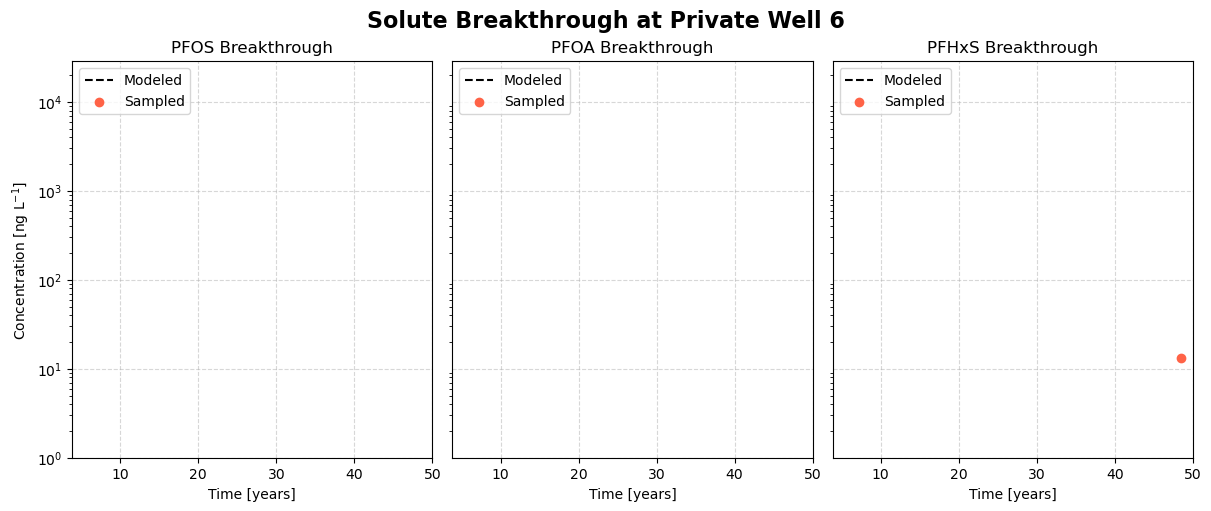

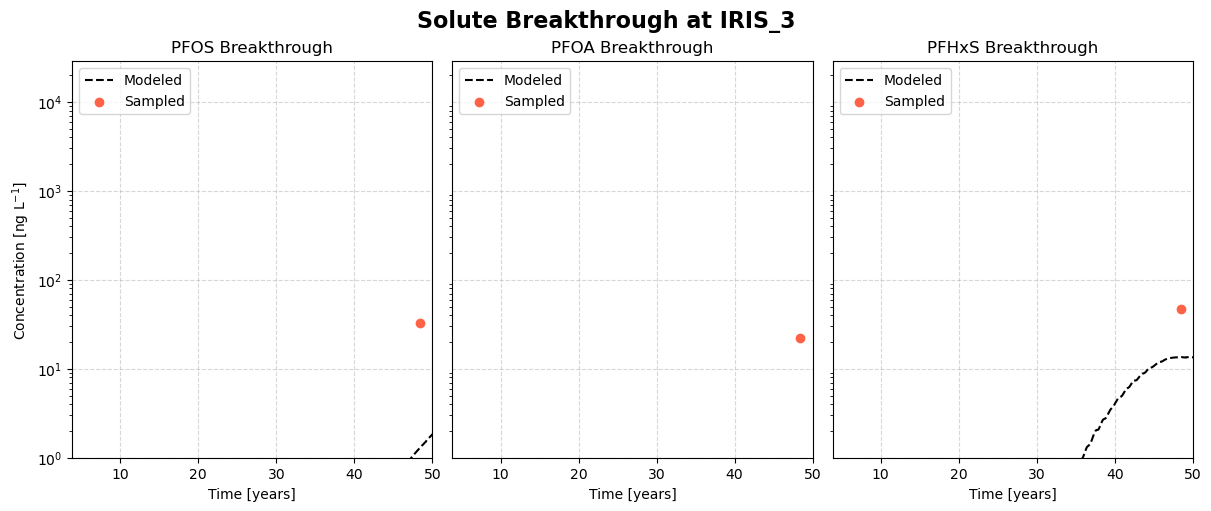

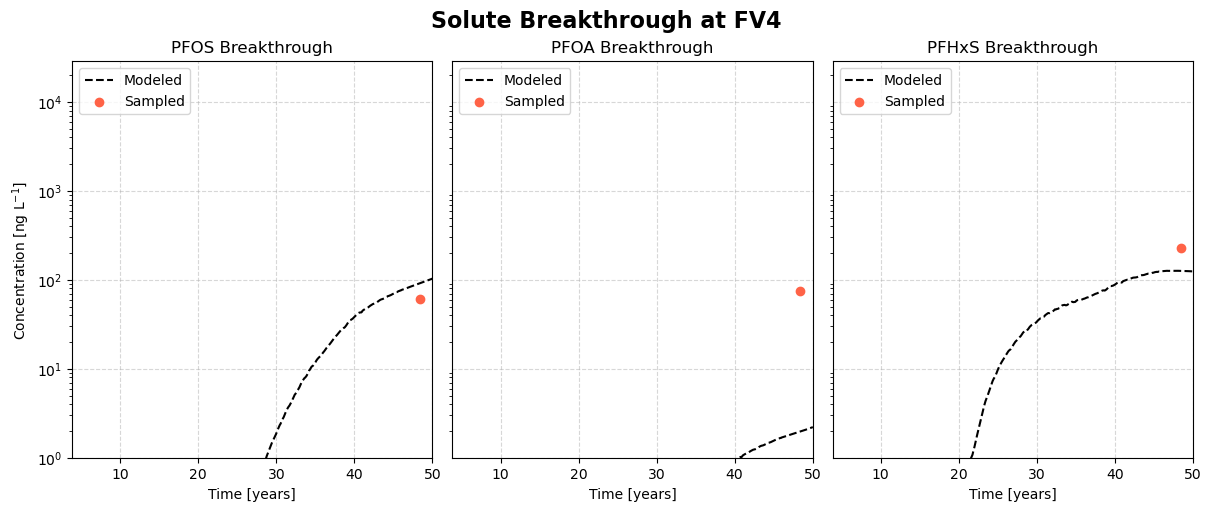

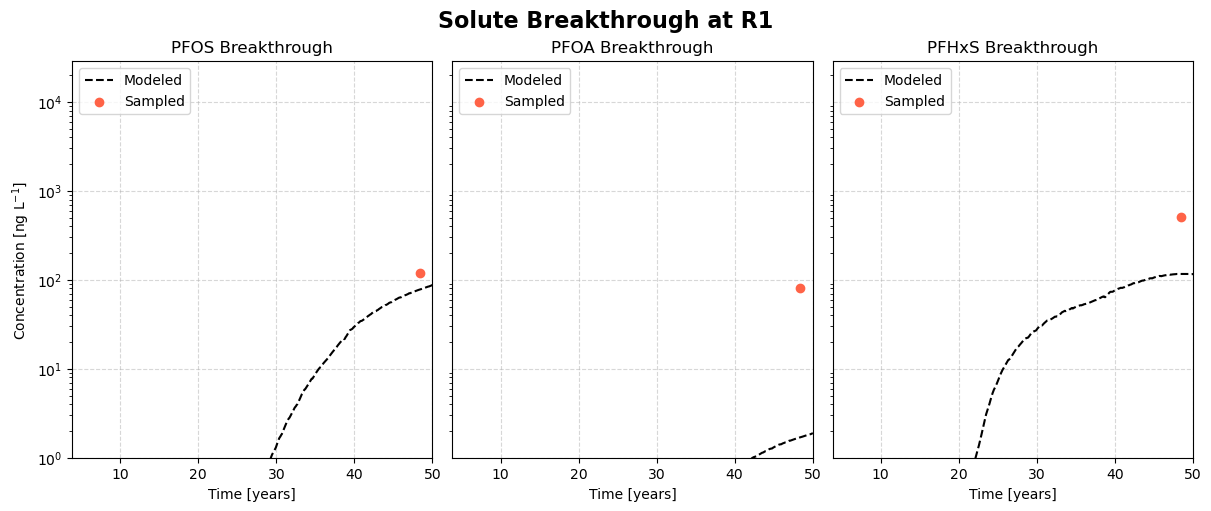

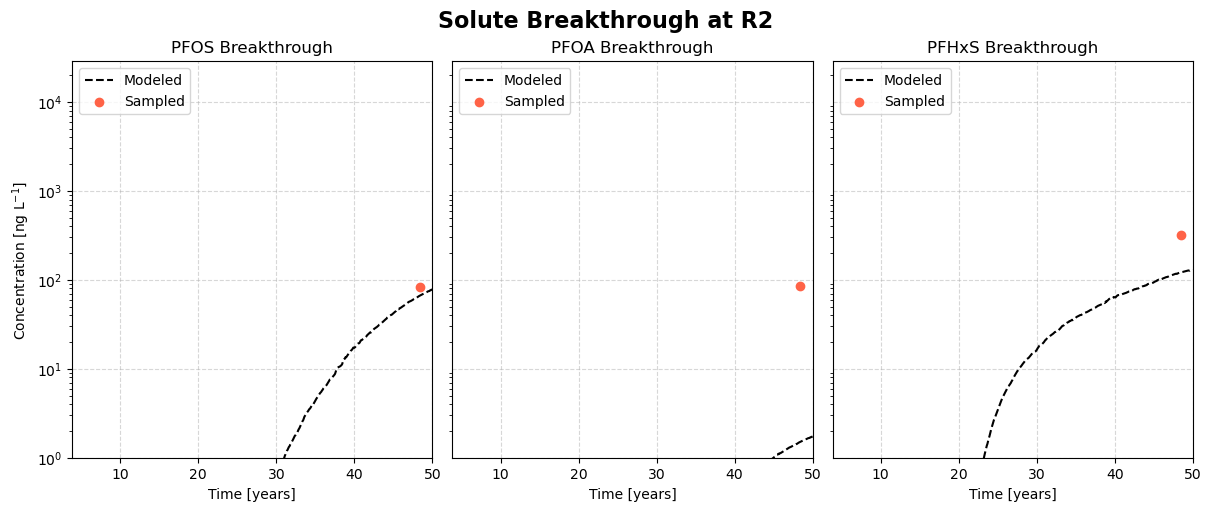

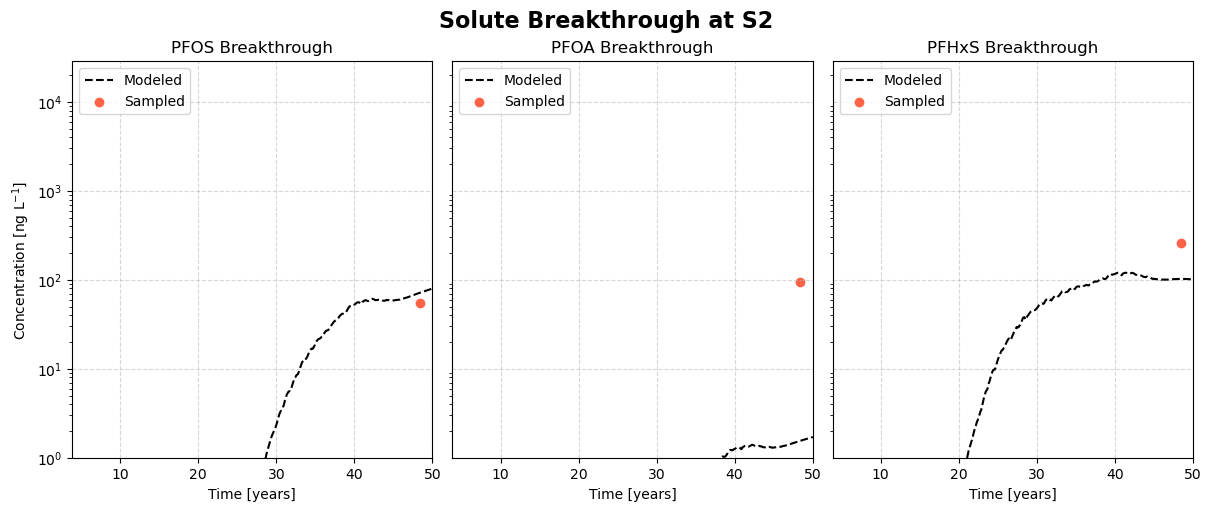

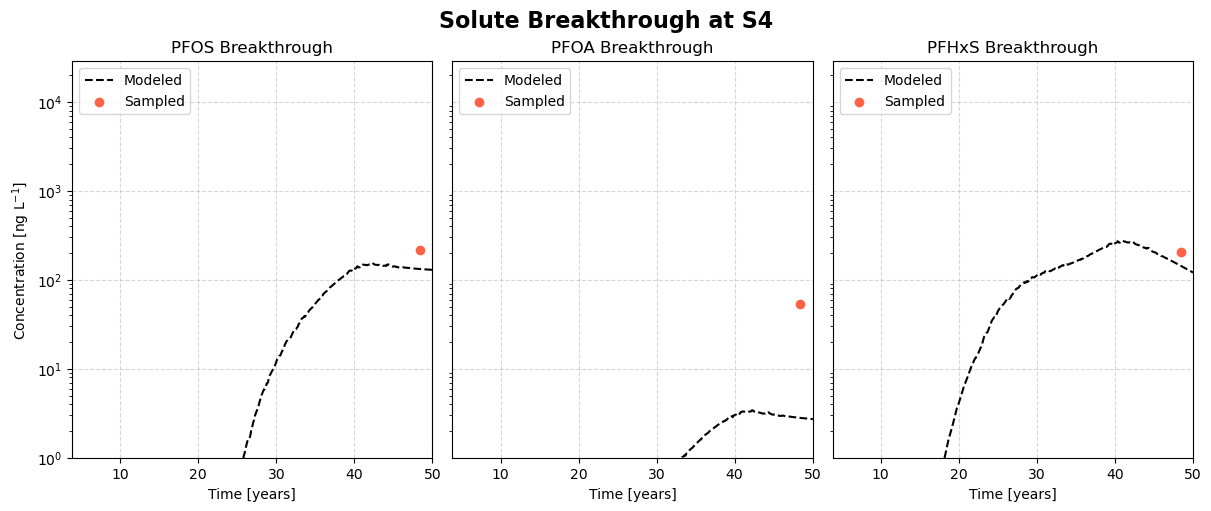

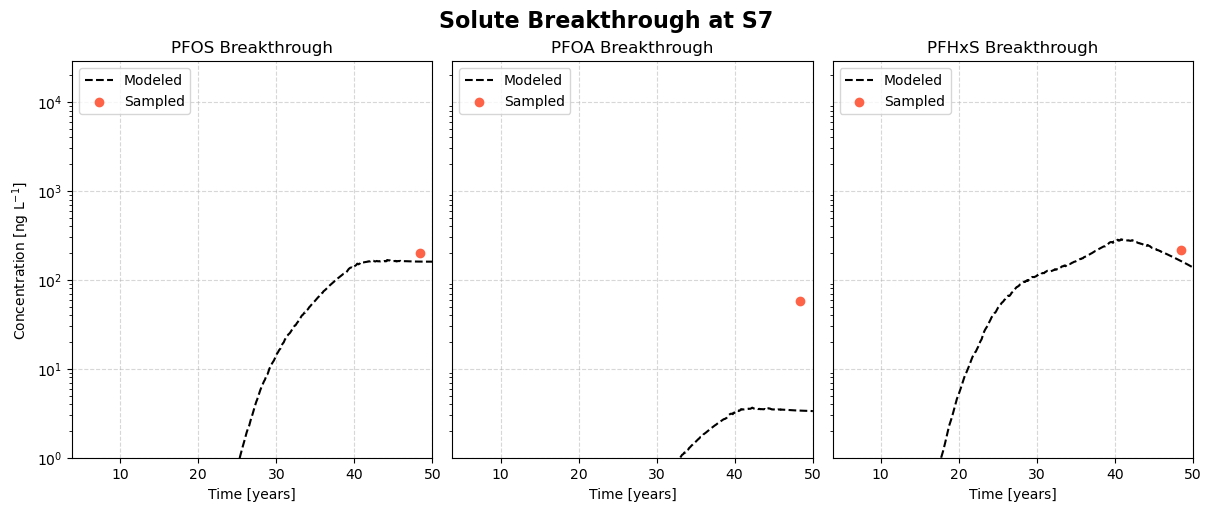

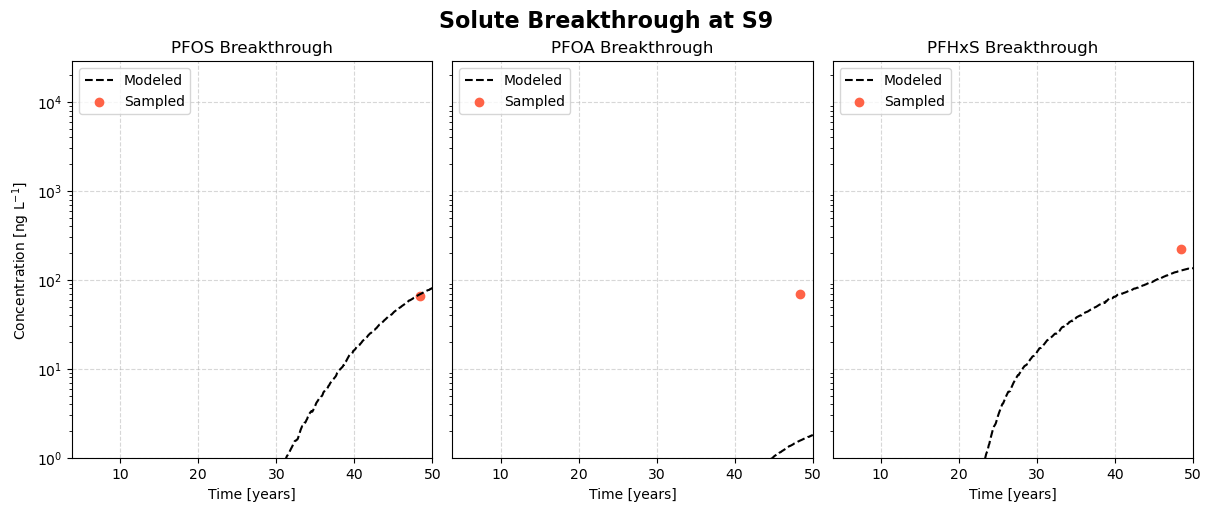

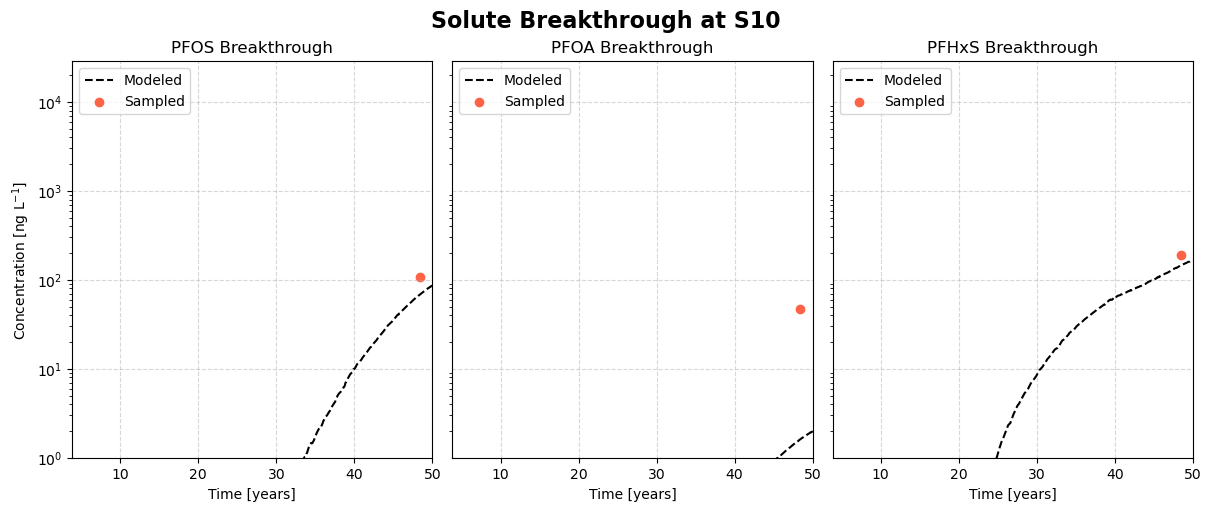

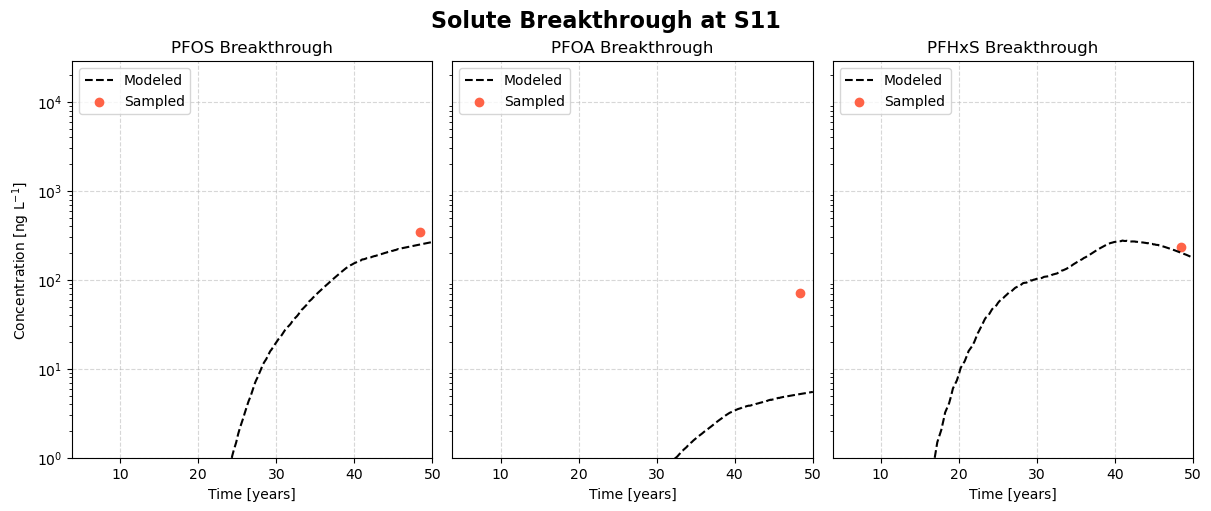

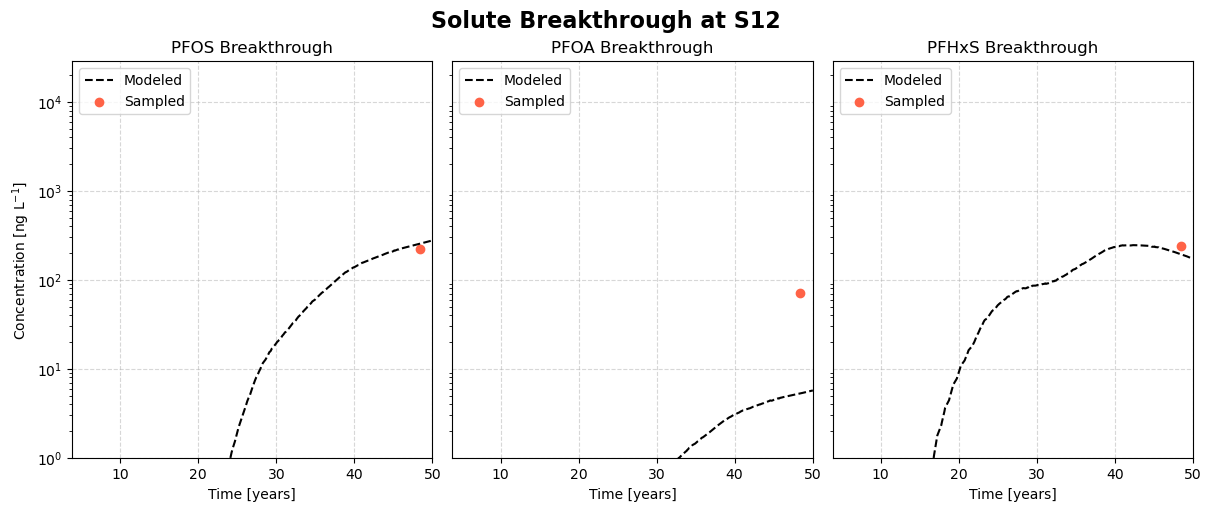

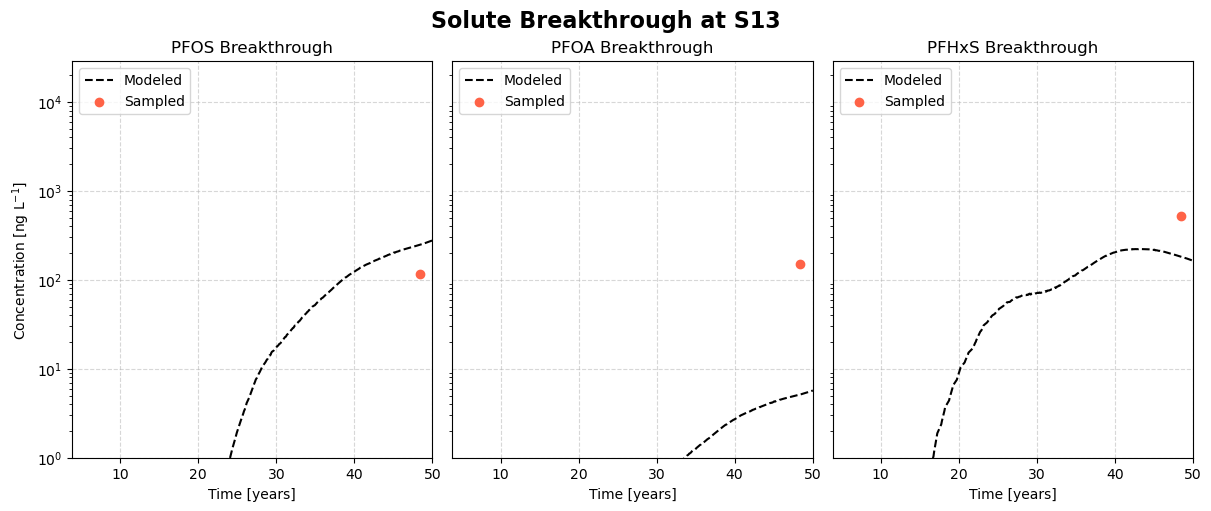

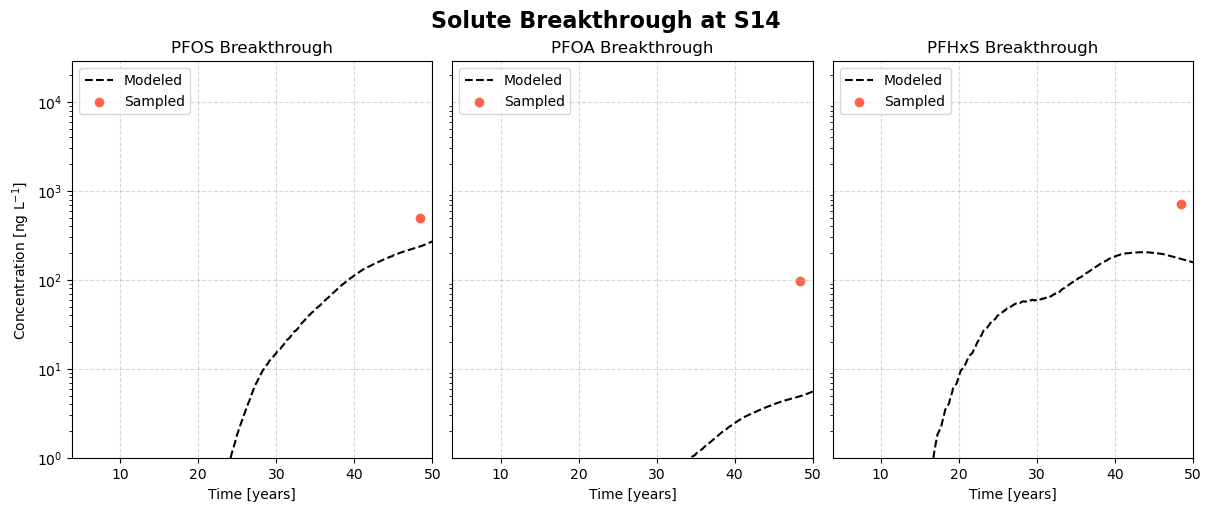

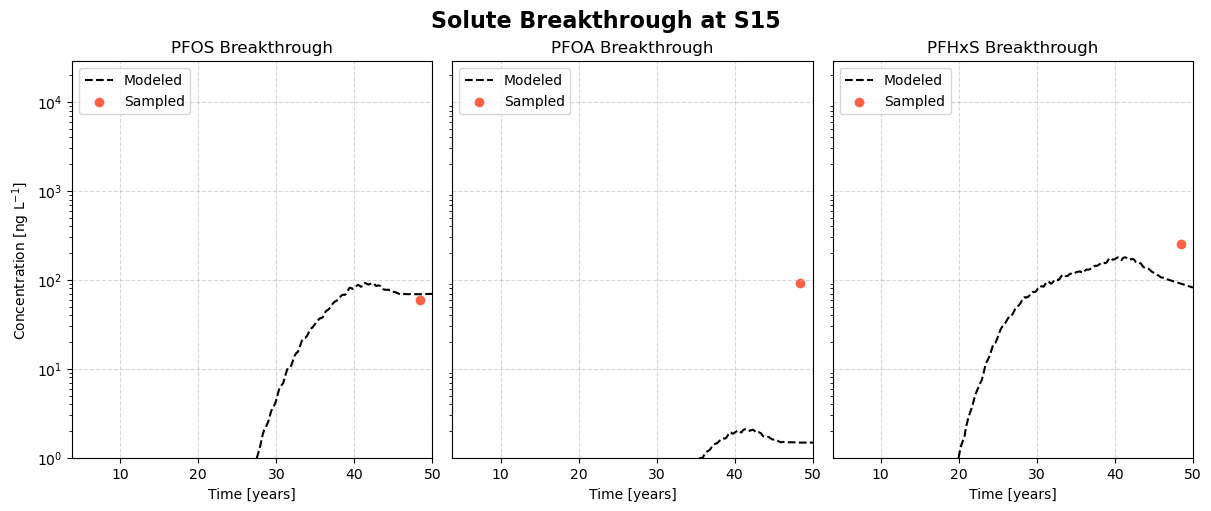

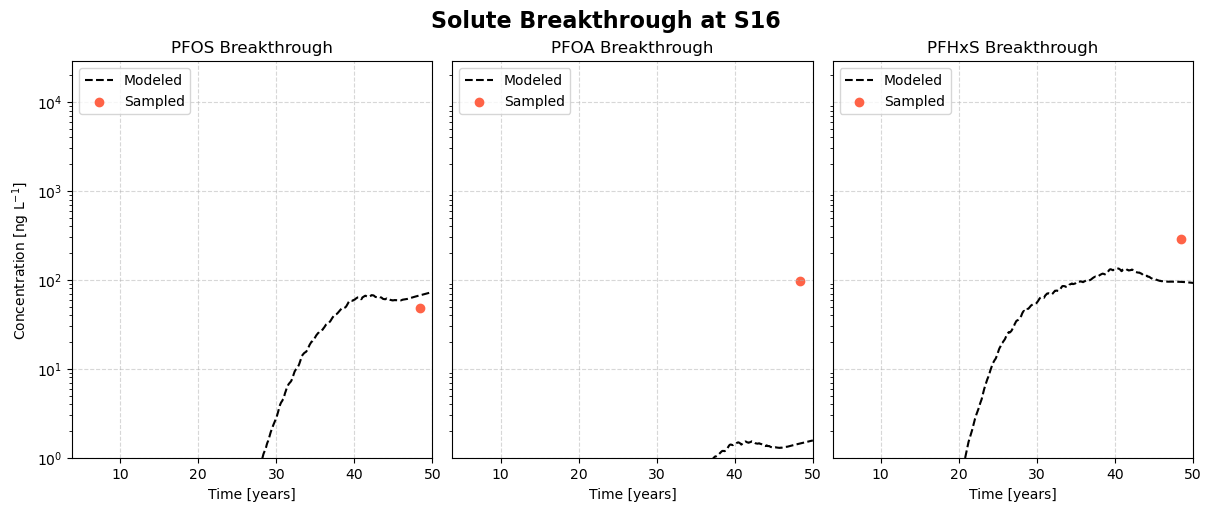

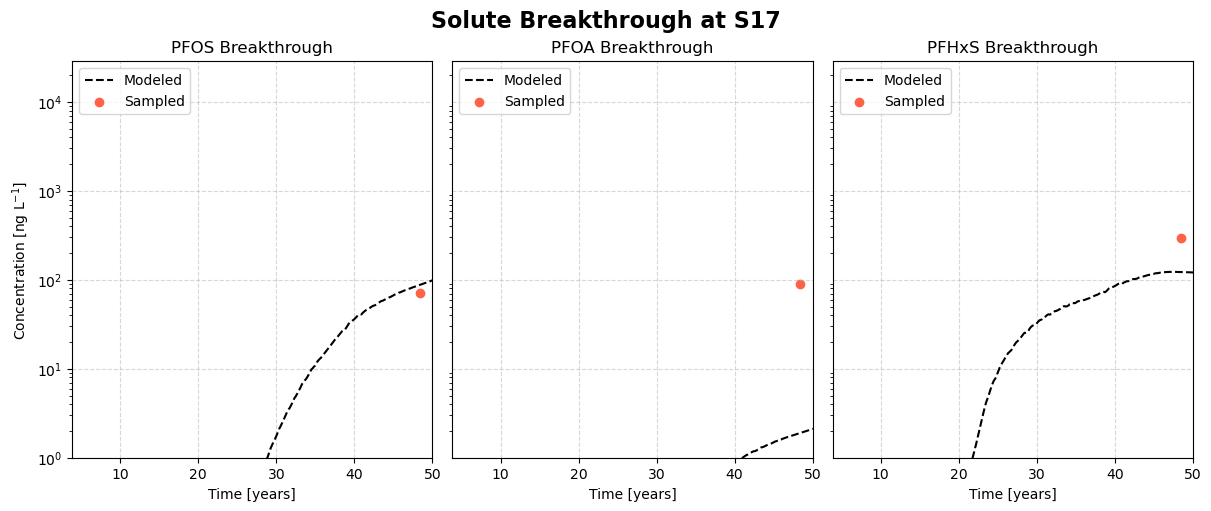

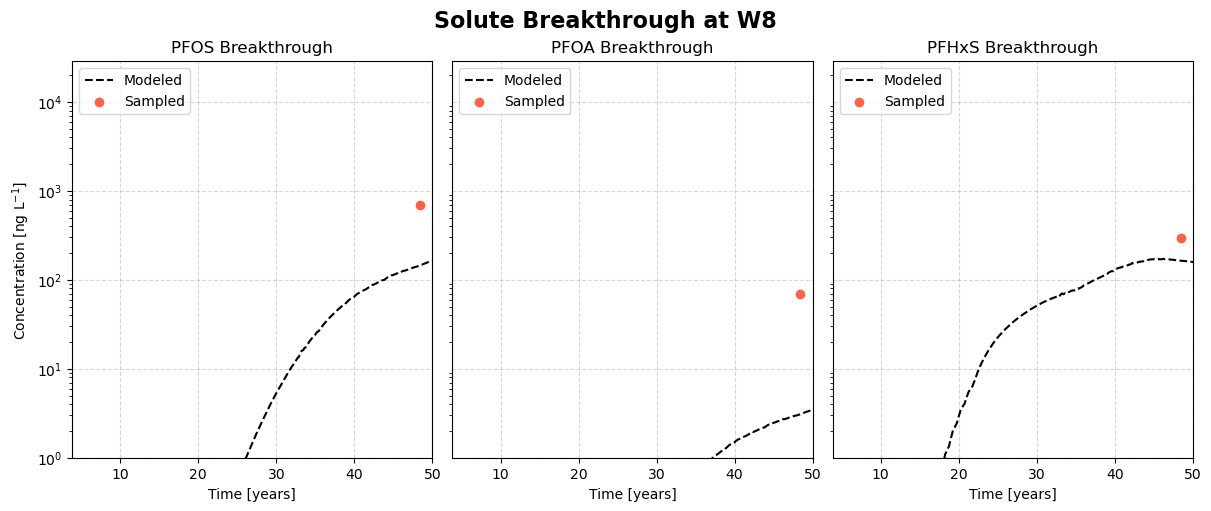

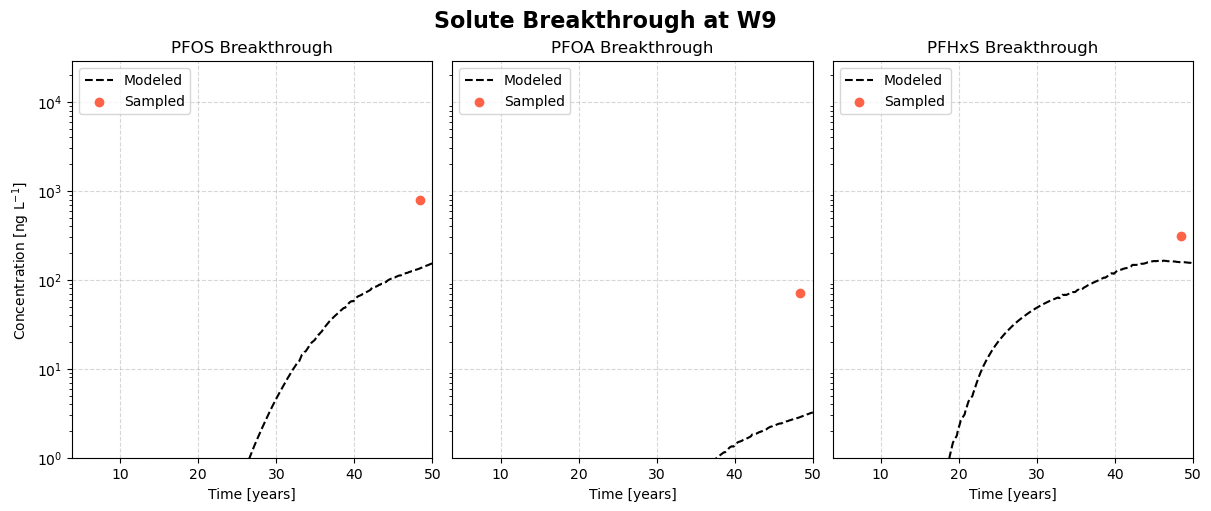

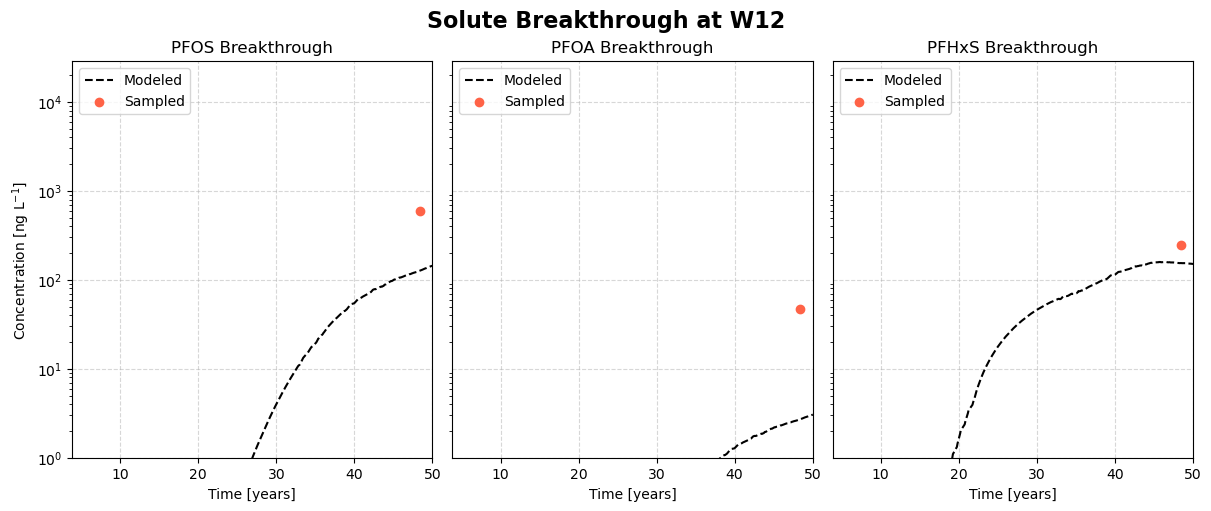

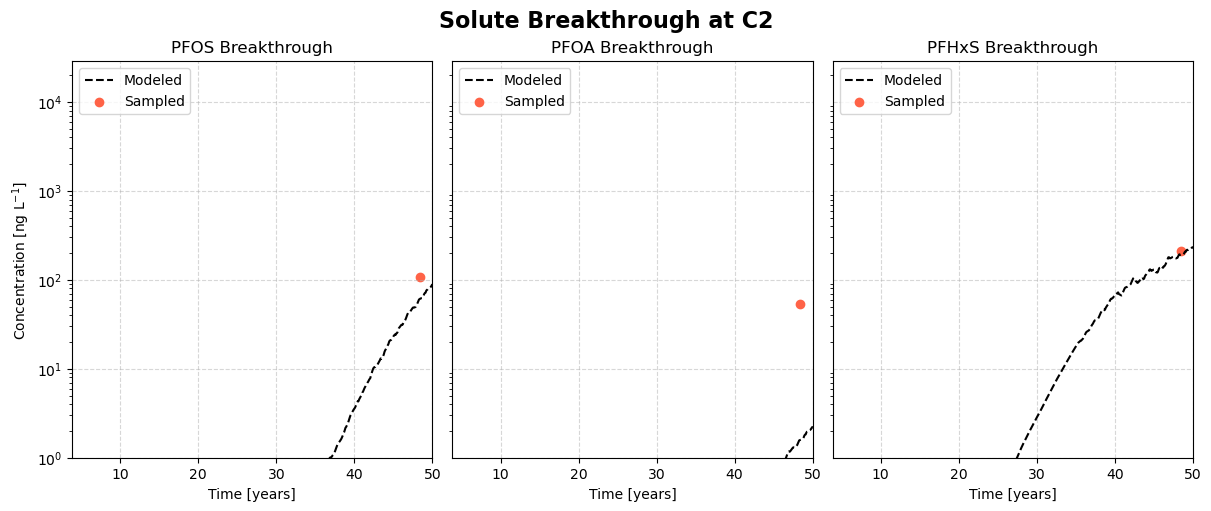

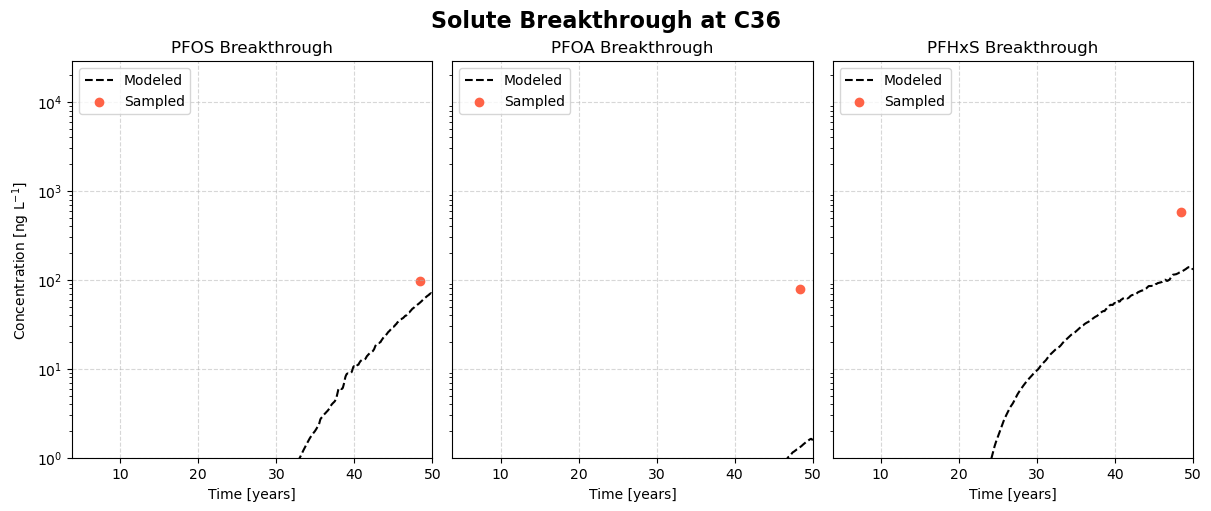

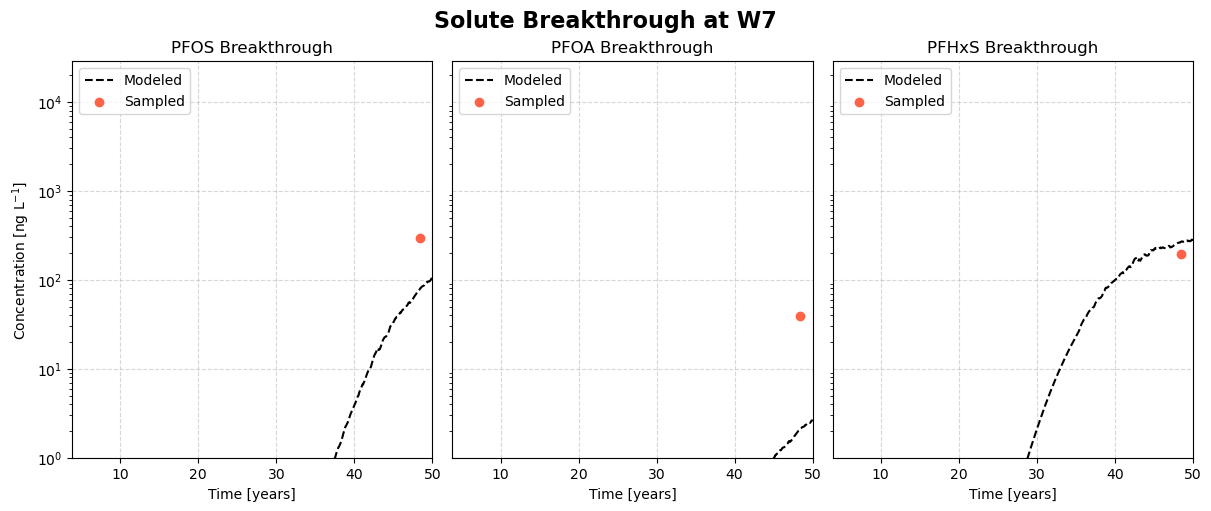

In [32]:
i = 0
for well in obs_pfos.keys():
    pfos_well = sim_pfos.loc[:, well]
    pfoa_well = sim_pfoa.loc[:, well]
    pfhxs_well = sim_pfhxs.loc[:, well]

    fig, axs = plt.subplots(1, 3, figsize=(12,5), layout='constrained')
    ax1, ax2, ax3 = axs
    
    # Plot pfos
    ax1.plot(sim_pfos.index/365, pfos_well*1e6, c='k', ls='--', label='Modeled')
    ax1.scatter(17682/365, obs_pfos[well], c='tomato', marker='o', label='Sampled')
    ax1.set_ylabel('Concentration [ng L$^{-1}$]')
    ax1.set_title('PFOS Breakthrough')
    
    # Plot pfoa
    ax2.plot(sim_pfoa.index/365, pfoa_well*1e6, c='k', ls='--', label='Modeled')
    ax2.scatter(17682/365, obs_pfoa[well], c='tomato', marker='o', label='Sampled')
    ax2.set_title('PFOA Breakthrough')

    ax3.plot(sim_pfhxs.index/365, pfhxs_well*1e6, c='k', ls='--', label='Modeled')
    ax3.scatter(17682/365, obs_pfhxs[well], c='tomato', marker='o', label='Sampled')
    ax3.set_title('PFHxS Breakthrough')
    
    ymax = max(sim_pfos.max().max(),sim_pfoa.max().max(),sim_pfhxs.max().max()) * 1e6
    buffer = ymax * .2
    
    for ax in axs:
        ax.set_xlabel('Time [years]')
    
        ax.set_yscale('log')
        ax.set_ylim(1, ymax+buffer)
        ax.set_xlim(1400/365, 50)
        ax.grid(ls='--', alpha=0.5)
        ax.legend(loc='upper left')

    # ax2.set_yticks([])    # Remove ticks
    # ax2.set_yticklabels([])  # Remove tick labels    
    ax2.set(yticklabels=[])  # remove the tick labels
    ax2.tick_params(left=False)  # remove the ticks
    
    ax3.set(yticklabels=[])  # remove the tick labels
    ax3.tick_params(left=False)  # remove the ticks
    
    if i < 6:
        plt.suptitle(f'Solute Breakthrough at Private Well {i+1}', fontsize=16, weight='bold')
    else:
        plt.suptitle(f'Solute Breakthrough at {well}', fontsize=16, weight='bold')
        
    # plt.savefig(f'C:/Users/jackp/OneDrive - Colorado School of Mines/Documents/model-features/breakthroughs-04-23/{pfos.name}.png', bbox_inches='tight', dpi=300)
    plt.show()

    i += 1